In [22]:
#imports 
import numpy as np 
import matplotlib.pyplot as plt

#original data set 
data = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])
x = np.array([i for i in range(1, len(data)+1)])

In [3]:
def plot_two(x1, y1, x2, y2, Title): #scatter plot first, spline second 
    plt.plot(x1, y1, 'o', label='Data')    # original data points
    plt.plot(x2, y2, '-', label='Spline')  # cubic spline curve
    plt.title(Title)
    plt.legend()
    plt.grid(True)
    plt.show()
# Since I am plotting a line compared to the data points multiple times
# I made a function to streamline the process 
    
def error(y, y_test, Title):
    # mean squared error 
    mse_v = np.mean((y - y_test)**2)

    # R squared
    ss_total_v = np.sum((y - np.mean(y))**2)
    ss_res_v = np.sum((y - y_test)**2)
    r_squared_v = 1 - (ss_res_v / ss_total_v)

    print(Title)
    print(f'mean squared error: {mse_v:0.4f}')
    print(f'r squared: {r_squared_v:0.4f}')
# This functions returns both the mean squared error and r squared value 
# Ideal value is MSE close to 0 and R squared close to 1 
# this allows for a measure of how accurately the graph captures the data  

In [7]:
#PART A
def tridiagonal(x, y):
    n = len(x)
    h = np.diff(x)
    A = np.zeros(n - 2)
    B = np.zeros(n - 2)
    C = np.zeros(n - 2)
    D = np.zeros(n - 2)

    for i in range(1, n - 1):
        A[i - 1] = h[i - 1] #lower diagonal 
        B[i - 1] = 2 * (h[i - 1] + h[i]) #main diagonal 
        C[i - 1] = h[i] #upper diagonal 
        D[i - 1] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])
        # ^^ right hand side 
    return A, B, C, D
# This function is solving for the second derivatives at interior points 

def thomas_algorithm(a, b, c, d):
    n = len(d)
    b = b.copy()
    d = d.copy()

    #forward elimination
    for i in range(1, n):
        w = a[i - 1] / b[i - 1]
        b[i] -= w * c[i - 1]
        d[i] -= w * d[i - 1]

    #back substitution
    M = np.zeros(n)
    M[-1] = d[-1] / b[-1]
    for i in range(n - 2, -1, -1):
        M[i] = (d[i] - c[i] * M[i + 1]) / b[i]
    return M # This is the solution vector 

def cubic_spline(x, y, x_point):

    #1) tridiagonal 
    A, B, C, D = tridiagonal(x, y)

    #2) thomas alg
    M_interior = thomas_algorithm(A, B, C, D)

    #3) boundary conditions
    n = len(x)
    M = np.zeros(n) # second derivatives at end points are zero 
    M[1:-1] = M_interior # inner values solved for previously 

    #4) evaluate spline
    for i in range(n - 1):
        if x[i] <= x_point <= x[i + 1]: # finds the range in which the point is on
            break

    h_i = x[i + 1] - x[i] #width of each interval

    term1 = M[i] * (x[i + 1] - x_point)**3 / (6 * h_i)
    term2 = M[i + 1] * (x_point - x[i])**3 / (6 * h_i)
    term3 = (y[i] - M[i] * h_i**2 / 6) * (x[i + 1] - x_point) / h_i
    term4 = (y[i + 1] - M[i + 1] * h_i**2 / 6) * (x_point - x[i]) / h_i

    return term1 + term2 + term3 + term4 # these are the terms of the cubic spline equation

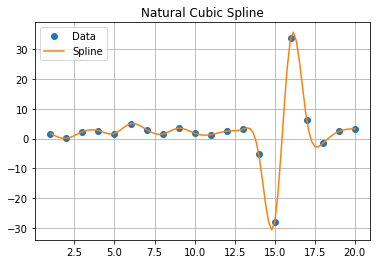

Error for Natural Spline
mean squared error: 0.0000
r squared: 1.0000


In [8]:
#Part A1: Natural Cubic Spline For Given Quarters
def plot_A1(): #Plot A1
    x_fine = np.linspace(x[0], x[-1], 100)
    y_spline = np.array([cubic_spline(x, data, xi) for xi in x_fine]) #evaluates spline at each x point
    y_pred = np.array([cubic_spline(x, data, xi) for xi in x])
    plot_two(x, data, x_fine, y_spline, 'Natural Cubic Spline')
    error(data, y_pred, "Error for Natural Spline")
# I want to find the cubic spline equation at each point
# I used a list of 100 points between the range of the dataset to get a smooth graph
# each of these x values are evaluated using the same cubic spline function 
plot_A1()

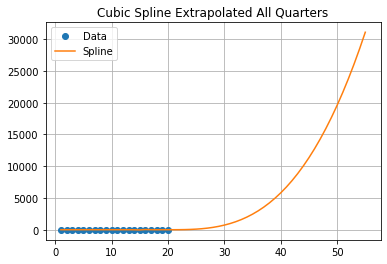

In [10]:
#Part A2: Natural Cubic Spline For All Quarters
x_a2 = np.array([i for i in range(1, 56)])

#Plot A2
def plot_A2(): #Plot A1
    y_spline = np.array([cubic_spline(x, data, xi) for xi in x_a2])
    #evaluates spline at each x point
    plot_two(x, data, x_a2, y_spline, 'Cubic Spline Extrapolated All Quarters')
# This plot creates a new list of x values that are supposed to demonstrate all quarters 
# The graph demonstrates that this method of interpolation is not suited for extrapolation 

plot_A2()

In [12]:
#PART B
def vandermonde_polynomial_fitting(degree, x, y):
    V = np.vander(x, N=degree+1, increasing=True) 
    #columns go x^0, x^1, ... 
    VT_V = V.T @ V
    VT_y = V.T @ y
    # this is least squares polynomial fitting
    coefficients_v = np.linalg.solve(VT_V, VT_y)

    # reverse coefficients for np.poly1d
    poly_v = np.poly1d(coefficients_v[::-1])

    # predict y values
    y_pred = poly_v(x)
    return y_pred
# it makes the equation to best fit the data with a polynomial of a specified degree 

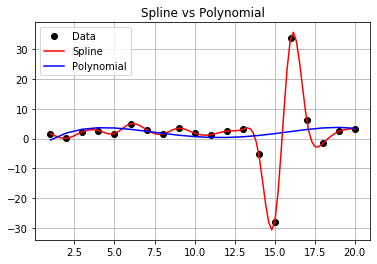

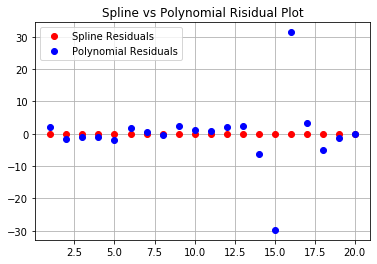

Error for 4th Degree Polynomial
mean squared error: 99.3077
r squared: 0.0166


In [20]:
#Part B1: 4th Degree Polynomial Fit w/ Least Squares
def plot_B1():
    #polynomial
    degree = 4
    y_pred = vandermonde_polynomial_fitting(4, x, data)
    
    #spline
    x_fine = np.linspace(x[0], x[-1], 100)
    y_spline = np.array([cubic_spline(x, data, xi) for xi in x_fine])
    y_spline_er = np.array([cubic_spline(x, data, xi) for xi in x])
    
    plt.plot(x, data, 'ko', label='Data')          # original data points
    plt.plot(x_fine, y_spline, 'r-', label='Spline')    # cubic spline curve
    plt.plot(x, y_pred, 'b-', label='Polynomial')  # polynomial
    plt.title("Spline vs Polynomial")
    plt.legend()
    plt.grid(True)
    plt.show()
    #this creates a graph that plots the cubic spline from before and the 4th degree polynomial
    # the data points are plotted as a scatter plot for refrence 

    r_spline = data - y_spline_er
    r_pred = data - y_pred
    # this finds the residuals for each of the lines 
    
    plt.plot(x, r_spline, 'ro', label="Spline Residuals")
    plt.plot(x, r_pred, 'bo', label="Polynomial Residuals")
    plt.title('Spline vs Polynomial Risidual Plot')
    plt.legend()
    plt.grid(True)
    plt.show()
    # this graphs the residuals of both graphs 
    
    error(data, y_pred, "Error for 4th Degree Polynomial")

plot_B1()

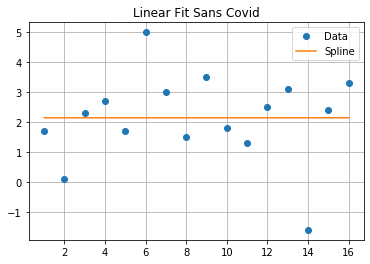

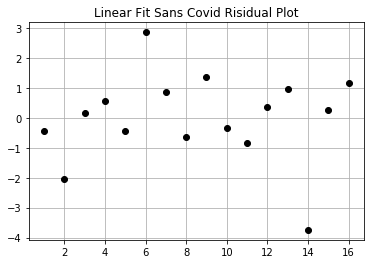

Error for Linear Fit Sans Covid
mean squared error: 2.0837
r squared: 0.0000


In [21]:
#Part B2: Linear Fit Sans Covid Data 
def plot_B2():
    dataNoCovid = np.delete(data, slice(13, 17))
    xNoCovid = np.delete(x, slice(16, 20))
    y_pred = vandermonde_polynomial_fitting(1, xNoCovid, dataNoCovid)
    # this removes the outlier data points caused by covid
    # with polynomial fitting, a linear equation is created 

    plot_two(xNoCovid, dataNoCovid, xNoCovid, y_pred, 'Linear Fit Sans Covid')
    # graphs the linear line and the data points 
    r = dataNoCovid - y_pred 
    plt.plot(xNoCovid, r, 'ko')
    #graphs the residuals of data points and linear line 
    plt.title('Linear Fit Sans Covid Risidual Plot')
    plt.grid(True)
    plt.show()

    error(dataNoCovid, y_pred, "Error for Linear Fit Sans Covid")

plot_B2()